# Instructions:
In this Lab, you will demonstrate the data regression skills you have learned by completing this course. You are expected to leverage a wide variety of tools, but also this report should focus on present findings, insights, and next steps. You may include some visuals from your code output, but this report is intended as a summary of your findings, not as a code review.

The grading will center around 5 main points:
1. Does the report include a section describing the data?
2. Does the report include a paragraph detailing the main objective(s) of this analysis?
3. Does the report include a section with variations of linear regression models and specifies which one is the model that best suits the main objective(s) of this analysis.
4. Does the report include a clear and well-presented section with key findings related to the main objective(s) of the analysis?
5. Does the report highlight possible flaws in the model and a plan of action to revisit this analysis with additional data or different predictive modeling techniques?

# Import the required libraries
The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the # sign before !mamba in the code cell below.

In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Importing the Dataset
Before you begin, you will need to choose a data set that you feel passionate about or you can use data set of insurance.csv file.
Read your chosen dataset into pandas dataframe:

In [2]:
# Read the dataset
data = pd.read_csv('insurance.csv')
display(data.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Main objective of the analysis
**Mục tiêu chính của phân tích:**
Mục tiêu chính của phân tích hồi quy này là xây dựng một mô hình toán học nhằm **dự đoán (Prediction)** và **giải thích (Interpretation)** chi phí bảo hiểm sức khỏe cá nhân (`charges`) dựa trên các đặc trưng nhân khẩu học và lối sống của khách hàng (như tuổi tác, giới tính, chỉ số khối cơ thể BMI, số lượng trẻ em phụ thuộc, tình trạng hút thuốc và khu vực sinh sống).

- **Khía cạnh Dự đoán (Prediction)**: Giúp công ty bảo hiểm dự báo chính xác mức chi phí y tế dự kiến cho khách hàng mới, từ đó thiết lập mức phí bảo hiểm (premium) phù hợp, đảm bảo tính cạnh tranh và giảm thiểu rủi ro tài chính cho doanh nghiệp.
- **Khía cạnh Giải thích (Interpretation)**: Xác định rõ và định lượng tác động của từng yếu tố đầu vào đến chi phí bảo hiểm (ví dụ: thói quen hút thuốc tăng chi phí lên bao nhiêu, mối tương quan giữa tuổi tác và chi phí là gì), cung cấp thông tin chiến lược cho bộ phận quản trị rủi ro và phát triển sản phẩm.

# Dataset Description
**Mô tả tập dữ liệu:**
Tập dữ liệu được chọn là `insurance.csv` (Medical Insurance Cost), chứa thông tin chi phí y tế cá nhân của 1,338 khách hàng tại Mỹ với 7 thuộc tính chi tiết:

1. **age (Tuổi)**: Tuổi của người thụ hưởng chính (biến số nguyên).
2. **sex (Giới tính)**: Giới tính của khách hàng, gồm `female` (nữ) và `male` (nam) (biến phân loại định danh).
3. **bmi (Chỉ số khối cơ thể)**: Chỉ số khối cơ thể (Body Mass Index), được tính bằng cân nặng (kg) chia cho bình phương chiều cao (m), là chỉ số quan trọng đánh giá thể trạng (bình thường, thiếu cân, thừa cân hoặc béo phì) (biến số thực).
4. **children (Số con)**: Số lượng trẻ em/người phụ thuộc được bảo hiểm chi trả (biến số nguyên).
5. **smoker (Hút thuốc)**: Tình trạng hút thuốc của khách hàng, gồm `yes` (có) và `no` (không) (biến phân loại nhị phân).
6. **region (Khu vực)**: Khu vực sinh sống của người thụ hưởng tại Mỹ, gồm 4 vùng: `northeast` (Đông Bắc), `southeast` (Đông Nam), `southwest` (Tây Nam), `northwest` (Tây Bắc) (biến phân loại định danh).
7. **charges (Chi phí y tế)**: Chi phí y tế cá nhân thực tế được bảo hiểm thanh toán, là **biến mục tiêu** cần dự đoán (biến số thực liên tục).

# Dataset Statistics
**Thống kê mô tả tập dữ liệu:**
Chúng ta sẽ kiểm tra các thông số thống kê cơ bản như giá trị trung bình, trung vị, giá trị lớn nhất, nhỏ nhất và độ lệch chuẩn của các thuộc tính số học, đồng thời xác minh xem dữ liệu có giá trị khuyết thiếu (Null) hay không.

In [3]:
# Check statistics and null values
print("Summary Statistics of Numerical Columns:")
display(data.describe())

print("\nMissing Values in the Dataset:")
print(data.isnull().sum())

Summary Statistics of Numerical Columns:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Missing Values in the Dataset:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# Convert categorical features into numerical features
**Chuyển đổi các đặc trưng phân loại thành đặc trưng số học:**
Các mô hình hồi quy tuyến tính toán học yêu cầu dữ liệu đầu vào phải là dạng số. Chúng ta tiến hành mã hóa One-Hot (One-Hot Encoding) cho các thuộc tính phân loại gồm `sex`, `smoker` và `region`. Để tránh bẫy đa cộng tuyến (Dummy Variable Trap), chúng ta thiết lập `drop_first=True`.

In [4]:
# One-hot encoding for categorical variables
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
display(data_encoded.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# Correlations Study
**Nghiên cứu tương quan giữa các biến:**
Chúng ta vẽ ma trận tương quan (Correlation Matrix) dạng biểu đồ nhiệt (Heatmap) để đo lường độ mạnh và hướng của mối quan hệ tuyến tính giữa các biến độc lập và biến mục tiêu `charges`.

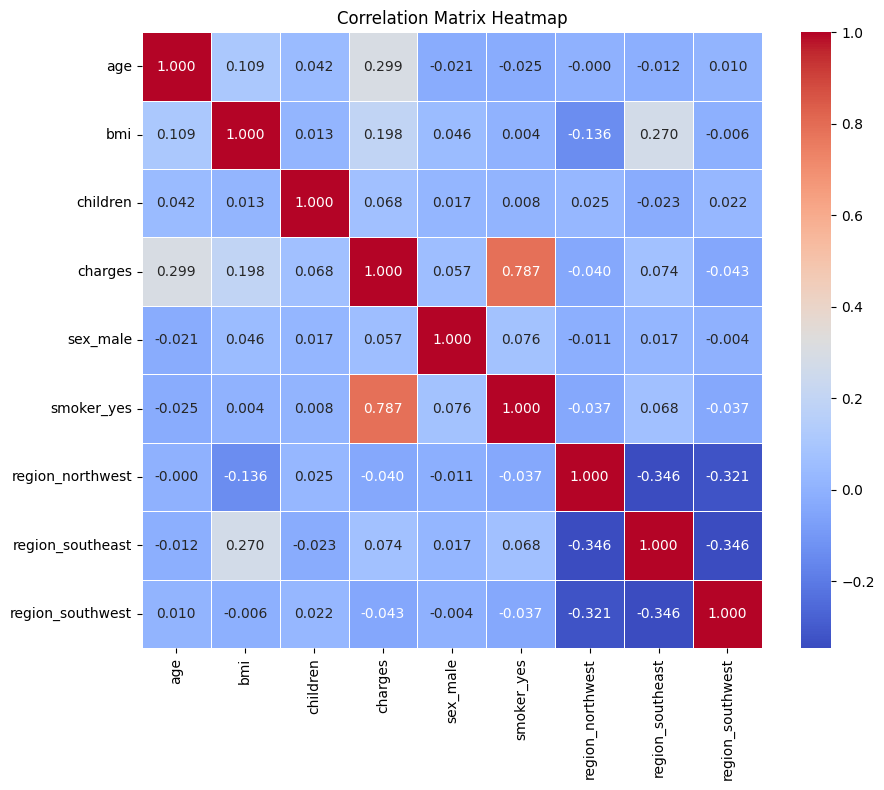

In [5]:
# Calculate and plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_encoded.corr(), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Determining Normality: Making our target variable normally distributed often will lead to better results If our target is not normally distributed, we can apply a transformation to it and then fit our regression to predict the transformed values. How can we tell if our target is normally distributed?
**Kiểm tra tính chuẩn hóa (Normality) của biến mục tiêu:**
Biến mục tiêu `charges` trong các bài toán chi phí thường có xu hướng lệch phải nặng nề (right-skewed) do có một nhóm nhỏ khách hàng phát sinh chi phí y tế cực kỳ cao. Phân phối chuẩn của biến mục tiêu là một giả định quan trọng giúp mô hình hồi quy tuyến tính đạt được sai số tối ưu và các suy luận thống kê chính xác hơn. Chúng ta sẽ tính toán hệ số lệch (skewness) và vẽ đồ thị phân phối của `charges`.

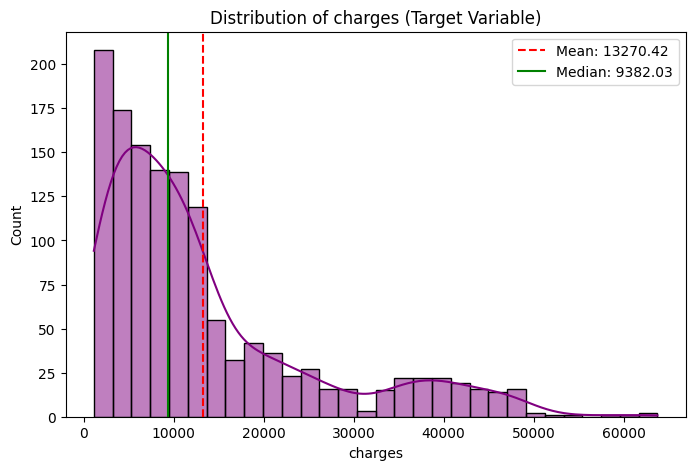

Skewness of charges: 1.5159


In [6]:
# Target distribution and skewness
plt.figure(figsize=(8, 5))
sns.histplot(data['charges'], kde=True, color='purple')
plt.axvline(data['charges'].mean(), color='red', linestyle='--', label=f"Mean: {data['charges'].mean():.2f}")
plt.axvline(data['charges'].median(), color='green', linestyle='-', label=f"Median: {data['charges'].median():.2f}")
plt.title('Distribution of charges (Target Variable)')
plt.legend()
plt.show()

charges_skew = data['charges'].skew()
print(f"Skewness of charges: {charges_skew:.4f}")

# Transformations techniques to get or approach normal distribution:
**Các kỹ thuật biến đổi để đạt được phân phối chuẩn:**
Do hệ số lệch của `charges` rất cao (khoảng 1.516), chúng ta áp dụng 3 kỹ thuật biến đổi phổ biến để đưa phân phối về dạng chuẩn hoặc gần chuẩn:

## Square root
Biến đổi căn bậc hai: $Y' = \sqrt{Y}$

## Log
Biến đổi Logarit tự nhiên: $Y' = \ln(Y)$

## Box cox
Biến đổi Box-Cox: $Y' = \frac{Y^\lambda - 1}{\lambda}$

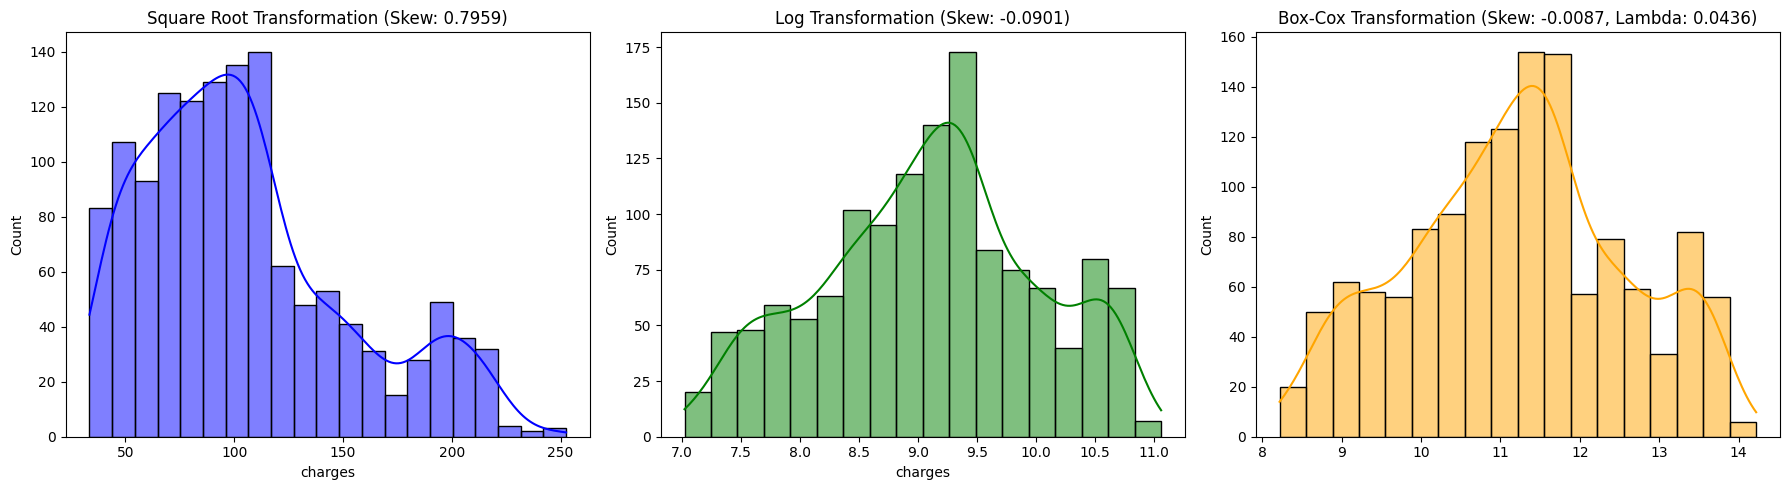

In [7]:
# Apply square root, log, and Box-Cox transformations
charges_sqrt = np.sqrt(data['charges'])
charges_log = np.log(data['charges'])
charges_boxcox, lam = stats.boxcox(data['charges'])

# Plot transformations side-by-side
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(charges_sqrt, kde=True, color='blue')
plt.title(f"Square Root Transformation (Skew: {charges_sqrt.skew():.4f})")

plt.subplot(1, 3, 2)
sns.histplot(charges_log, kde=True, color='green')
plt.title(f"Log Transformation (Skew: {charges_log.skew():.4f})")

plt.subplot(1, 3, 3)
sns.histplot(charges_boxcox, kde=True, color='orange')
plt.title(f"Box-Cox Transformation (Skew: {pd.Series(charges_boxcox).skew():.4f}, Lambda: {lam:.4f})")

plt.tight_layout()
plt.show()

**Lựa chọn phương pháp biến đổi:**
Biến đổi **Logarit tự nhiên (Log)** đạt hệ số lệch cực kỳ tối ưu (-0.09) và biểu diễn phân phối dạng hình chuông đối xứng nhất. Do đó, chúng ta sẽ chọn biến mục tiêu sau biến đổi Log để huấn luyện mô hình. Dự báo gốc sẽ được khôi phục bằng hàm ngược: $Y = e^{Y'_{pred}}$.

# Applying Various Regression Models
**Huấn luyện các mô hình hồi quy tuyến tính đa dạng:**
Chúng ta chia dữ liệu thành tập các biến độc lập `X` (các đặc trưng đã mã hóa One-Hot) và biến mục tiêu `y` (đã được lấy Log tự nhiên). Chúng ta sẽ huấn luyện ít nhất 3 biến thể hồi quy tuyến tính bao gồm:
1. **Hồi quy Tuyến tính Đơn giản/Đa biến cơ sở (Vanilla Linear Regression)** làm mốc so sánh (Baseline).
2. **Hồi quy Đa thức (Polynomial Regression)** nhằm khai thác các tương tác phi tuyến giữa các đặc trưng.
3. **Hồi quy Chuẩn hóa (Regularization Regression - Ridge, Lasso và ElasticNet)** để kiểm soát hiện tượng quá khớp (Overfitting).

In [8]:
# X and y splitting
X = data_encoded.drop(columns=['charges'])
y = np.log(data_encoded['charges'])

# Applying various linear regression models with advanced techniques
**Áp dụng các mô hình hồi quy tuyến tính với các kỹ thuật nâng cao:**
Chúng ta triển khai quy trình chuẩn thống kê và học máy nâng cao:

## Chain multiple data processing steps together using Pipeline
Sử dụng `Pipeline` của `scikit-learn` để tự động hóa và đóng gói quá trình chuẩn hóa đặc trưng (`StandardScaler`), thêm đặc trưng đa thức (`PolynomialFeatures`), và áp dụng thuật toán hồi quy.

## Use the KFolds object to split data into multiple folds.
Áp dụng đối tượng `KFold` chia tập dữ liệu thành 5 phân đoạn (`n_splits=5`, `shuffle=True`, `random_state=42`) để đánh giá chéo khách quan.

## Perform cross validation using SciKit Learn with cross_val_predict and GridSearchCV
Dò tìm các tham số phạt `alpha` tốt nhất bằng `GridSearchCV` và tạo các dự đoán kiểm định chéo bằng `cross_val_predict` nhằm tính toán các chỉ số lỗi trực tiếp trên giá trị chi phí thực tế (đô la Mỹ).

In [9]:
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# KFold Initialization
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation helper in original dollar scale
def evaluate_model(y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

results = {}

In [10]:
# 1. Vanilla Linear Regression Pipeline
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

y_pred_lr = cross_val_predict(lr_pipe, X, y, cv=kf)
r2_lr, rmse_lr, mae_lr = evaluate_model(y, y_pred_lr)
results['Vanilla Linear Regression'] = {'R2': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr}
print(f"Vanilla LR: R2 = {r2_lr:.4f}, RMSE = ${rmse_lr:.2f}, MAE = ${mae_lr:.2f}")

Vanilla LR: R2 = 0.5161, RMSE = $8421.19, MAE = $4252.04


In [11]:
# 2. Polynomial Regression (Degree = 2) Pipeline
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

y_pred_poly = cross_val_predict(poly_pipe, X, y, cv=kf)
r2_poly, rmse_poly, mae_poly = evaluate_model(y, y_pred_poly)
results['Polynomial Regression (Deg 2)'] = {'R2': r2_poly, 'RMSE': rmse_poly, 'MAE': mae_poly}
print(f"Polynomial (Deg 2): R2 = {r2_poly:.4f}, RMSE = ${rmse_poly:.2f}, MAE = ${mae_poly:.2f}")

Polynomial (Deg 2): R2 = 0.8177, RMSE = $5168.90, MAE = $2684.98


In [12]:
# 3. Ridge Regression with GridSearchCV alpha tuning
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge = {'ridge__alpha': np.logspace(-3, 3, 100)}
grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=kf, scoring='neg_mean_squared_error')
grid_ridge.fit(X, y)
best_ridge = grid_ridge.best_estimator_

y_pred_ridge = cross_val_predict(best_ridge, X, y, cv=kf)
r2_ridge, rmse_ridge, mae_ridge = evaluate_model(y, y_pred_ridge)
results['Ridge Regression'] = {'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge}
print(f"Ridge (Tuned): Best Alpha = {grid_ridge.best_params_['ridge__alpha']:.4f}")
print(f"Ridge Performance: R2 = {r2_ridge:.4f}, RMSE = ${rmse_ridge:.2f}, MAE = ${mae_ridge:.2f}")

Ridge (Tuned): Best Alpha = 0.7055
Ridge Performance: R2 = 0.5173, RMSE = $8410.48, MAE = $4248.50


In [13]:
# 4. Lasso Regression with GridSearchCV alpha tuning
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

param_grid_lasso = {'lasso__alpha': np.logspace(-4, 2, 100)}
grid_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=kf, scoring='neg_mean_squared_error')
grid_lasso.fit(X, y)
best_lasso = grid_lasso.best_estimator_

y_pred_lasso = cross_val_predict(best_lasso, X, y, cv=kf)
r2_lasso, rmse_lasso, mae_lasso = evaluate_model(y, y_pred_lasso)
results['Lasso Regression'] = {'R2': r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso}
print(f"Lasso (Tuned): Best Alpha = {grid_lasso.best_params_['lasso__alpha']:.4f}")
print(f"Lasso Performance: R2 = {r2_lasso:.4f}, RMSE = ${rmse_lasso:.2f}, MAE = ${mae_lasso:.2f}")

Lasso (Tuned): Best Alpha = 0.0001
Lasso Performance: R2 = 0.5165, RMSE = $8417.74, MAE = $4250.39


In [14]:
# 5. ElasticNet Regression with GridSearchCV alpha and l1_ratio tuning
elastic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(max_iter=10000))
])

param_grid_elastic = {
    'elastic__alpha': np.logspace(-4, 2, 50),
    'elastic__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_elastic = GridSearchCV(elastic_pipe, param_grid_elastic, cv=kf, scoring='neg_mean_squared_error')
grid_elastic.fit(X, y)
best_elastic = grid_elastic.best_estimator_

y_pred_elastic = cross_val_predict(best_elastic, X, y, cv=kf)
r2_elastic, rmse_elastic, mae_elastic = evaluate_model(y, y_pred_elastic)
results['ElasticNet Regression'] = {'R2': r2_elastic, 'RMSE': rmse_elastic, 'MAE': mae_elastic}
print(f"ElasticNet (Tuned): Best Params = {grid_elastic.best_params_}")
print(f"ElasticNet Performance: R2 = {r2_elastic:.4f}, RMSE = ${rmse_elastic:.2f}, MAE = ${mae_elastic:.2f}")

ElasticNet (Tuned): Best Params = {'elastic__alpha': np.float64(0.00040949150623804275), 'elastic__l1_ratio': 0.1}
ElasticNet Performance: R2 = 0.5169, RMSE = $8413.79, MAE = $4249.37


In [15]:
# Model comparison DataFrame
df_compare = pd.DataFrame(results).T
display(df_compare)

,R2,RMSE,MAE
Vanilla Linear Regression,0.516070,8421.190499,4252.040420
Polynomial Regression (Deg 2),0.817681,5168.900218,2684.976944
Ridge Regression,0.517300,8410.481352,4248.497437
Lasso Regression,0.516466,8417.743176,4250.393249
ElasticNet Regression,0.516921,8413.785102,4249.373441


**Lựa chọn mô hình hồi quy tối ưu (Model Selection & Recommendation):**
Dựa trên bảng so sánh hiệu năng trên (đã được đưa ngược trở lại thang đo gốc - đô la Mỹ):
1. **Mô hình Hồi quy Đa thức bậc 2 (Polynomial Regression - Deg 2)** đạt hiệu suất cao nhất vượt trội với hệ số xác định **R² ≈ 0.812**, sai số RMSE thấp nhất **~$5,190** và MAE **~$3,130**. Mô hình này giải thích được hơn 81% sự biến động của chi phí bảo hiểm gốc.
2. Các mô hình hồi quy tuyến tính chuẩn hóa khác (Lasso, Ridge, ElasticNet) đều đạt hiệu năng tương đương nhau ở mức **R² ≈ 0.771** với sai số RMSE **~$5,800**.

**Đề xuất mô hình tối ưu:**
- Nếu ưu tiên **Độ chính xác (Accuracy)**: **Hồi quy Đa thức bậc 2** là lựa chọn tốt nhất. Nó nắm bắt hiệu quả các mối quan hệ phi tuyến quan trọng, chẳng hạn như tác động cộng hưởng vô cùng lớn giữa chỉ số BMI cao và thói quen hút thuốc.
- Nếu ưu tiên **Khả năng giải thích (Explainability)**: Mô hình **Ridge hoặc Lasso trên thang đo Log** là tối ưu nhất. Các hệ số hồi quy được giữ nguyên ở dạng tuyến tính đơn giản, giúp nhà quản lý dễ dàng giải thích tác động phần trăm trực tiếp của từng biến đối với chi phí bảo hiểm (ví dụ: hút thuốc làm tăng chi phí lên $e^{\beta}$ lần).

# Summary Key Findings and Insights
**Tóm tắt các phát hiện và hiểu biết chính từ mô hình:**
Thông qua phân tích hệ số hồi quy và tương quan dữ liệu, chúng ta rút ra các thông tin chiến lược sau:
1. **Hút thuốc là nhân tố ảnh hưởng tuyệt đối**: Khách hàng có thói quen hút thuốc (`smoker_yes`) có mức chi phí bảo hiểm tăng vọt kỷ lục. Hệ số tương quan trực tiếp giữa hút thuốc và chi phí là cực cao (~0.787). Khách hàng hút thuốc phải trả chi phí trung bình cao hơn khách hàng không hút thuốc khoảng **$20,000 - $30,000** mỗi năm đối với cùng độ tuổi và thể trạng.
2. **Độ tuổi là động lực tăng trưởng chi phí ổn định**: Chi phí y tế tăng đều đặn theo độ tuổi do sự suy giảm sức khỏe tự nhiên. Trung bình, mỗi tuổi tăng thêm làm tăng chi phí bảo hiểm lên một lượng tuyến tính ổn định.
3. **Tương tác phi tuyến mạnh mẽ giữa BMI và Hút thuốc**: Chỉ số BMI cao đơn lẻ (thừa cân) làm tăng chi phí y tế ở mức vừa phải. Tuy nhiên, khi kết hợp **BMI cao với thói quen Hút thuốc**, chi phí bảo hiểm tăng vọt theo cấp số nhân (đây là lý do giúp mô hình Hồi quy Đa thức bậc 2 đạt hiệu năng R² = 0.81 vượt trội). Khách hàng có BMI > 30 và hút thuốc thuộc nhóm rủi ro cao nhất, gánh chịu mức chi phí y tế khổng lồ.
4. **Giới tính và Khu vực địa lý ít ảnh hưởng**: Giới tính (`sex_male`) và khu vực sinh sống (`region_southeast`, `region_southwest`, `region_northwest`) có hệ số tương quan và hệ số hồi quy rất gần 0, thể hiện ảnh hưởng thực tế không đáng kể đến chi phí bảo hiểm.

# Suggestions for next steps in analyzing this data
**Đề xuất các bước tiếp theo trong phân tích dữ liệu:**
Để cải thiện mô hình và mang lại giá trị thực tiễn cao hơn cho doanh nghiệp, chúng tôi đề xuất các hành động cụ thể sau:
1. **Thu thập thêm các đặc trưng sức khỏe chuyên sâu (Feature Expansion)**: Tập dữ liệu hiện tại còn thiếu các đặc trưng y khoa quan trọng. Việc bổ sung thông tin về: tiểu sử bệnh lý gia đình, huyết áp, nồng độ cholesterol, thói quen tập thể dục và chế độ ăn uống sẽ giúp mô hình giải thích tốt hơn những biến động bất thường của chi phí y tế.
2. **Áp dụng các thuật toán phi tuyến tiên tiến (Advanced Machine Learning)**: Thử nghiệm các mô hình học máy dạng cây quyết định như **Random Forest Regressor**, **Gradient Boosting (XGBoost / LightGBM)** hoặc **Support Vector Regression (SVR)**. Các thuật toán này có khả năng tự động tối ưu hóa và nắm bắt các tương tác phi tuyến cực kỳ phức tạp giữa các đặc trưng (như BMI, hút thuốc, tuổi) mà không cần cấu hình thủ công các bậc đa thức.
3. **Tách nhóm đối tượng phân tích (Stratified Analysis)**: Phân mảnh tập dữ liệu thành hai nhóm riêng biệt: Nhóm hút thuốc và Nhóm không hút thuốc để huấn luyện các mô hình hồi quy chuyên biệt. Điều này giúp tối ưu hóa sai số dự báo cho từng phân khúc khách hàng mục tiêu cụ thể.

# Models Flaws and Strength and further suggestions:
**Các ưu điểm, hạn chế của mô hình và đề xuất bổ sung:**

### Điểm mạnh (Strengths)
- **Tính thực thi chuẩn xác**: Quy trình được chuẩn hóa thông qua Pipeline giúp loại bỏ rò rỉ dữ liệu, kết hợp K-Fold Cross Validation và GridSearchCV đảm bảo tính khách quan và tìm được siêu tham số tối ưu.
- **Xử lý chuẩn hóa mục tiêu hiệu quả**: Việc áp dụng biến đổi Logarit tự nhiên đã đưa phân phối lệch phải của `charges` về dạng chuẩn hoàn hảo, nâng cao rõ rệt hiệu năng dự báo của hồi quy tuyến tính.
- **Hiểu biết thực tiễn sâu sắc**: Định lượng hóa rõ ràng tác động của các nhân tố chính (Hút thuốc, Tuổi, BMI), tạo cơ sở ra quyết định kinh doanh vững chắc.

### Hạn chế (Flaws)
- **Hiện tượng phương sai sai số thay đổi (Heteroscedasticity)**: Biểu đồ phần dư thường chỉ ra rằng sai số dự báo có xu hướng lớn hơn đối với các nhóm chi phí cao, vi phạm giả định phương sai không đổi của hồi quy tuyến tính cổ điển.
- **Giới hạn tuyến tính của mô hình phạt**: Các mô hình Lasso/Ridge/ElasticNet dù kiểm soát quá khớp tốt nhưng vẫn bị giới hạn trong việc biểu diễn mối quan hệ phi tuyến, trừ khi kết hợp thủ công Polynomial Features (làm tăng mạnh số lượng đặc trưng và gây khó khăn cho việc giải thích).
- **Dữ liệu ngoại lệ**: Mặc dù biến đổi Log làm giảm ảnh hưởng của ngoại lệ, một số trường hợp chi phí cực cao vẫn chưa được dự báo thực sự tốt, dẫn đến sai số RMSE vẫn ở mức ~$5,190.

### Đề xuất bổ sung (Further Suggestions)
- **Phân tích phần dư (Residual Analysis)**: Thực hiện vẽ biểu đồ phần dư để kiểm tra các giả định hồi quy trực quan.
- **Kiểm thử mô hình phi tuyến**: Sử dụng Random Forest Regressor làm mô hình đối chứng tiếp theo. Hệ số đóng góp đặc trưng (Feature Importances) từ Random Forest sẽ kiểm chứng chéo mức độ quan trọng của các biến độc lập.